# Bayesian Belief Updating: Discounting & Noise

**States** $s \in \{0, 1, 2\}$: Healthy, Sickness 1, Sickness 2  
**Symptoms** $x \in \{0, 1, 2\}$: Cough, Sneeze, Whistle

Three models compared:
1. **Optimal Bayes** — $\log p(s \mid x_{1:t}) \propto \log p(s) + \sum_{i=1}^{t} \log P(x_i \mid s)$
2. **Noisy, no discounting** — same but each log-likelihood is perturbed by $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, accumulated fully ($\alpha = 1$)
3. **Noisy + Discounted** — noisy updates with exponential discounting $\alpha < 1$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import logsumexp


In [ ]:
# ── Parameters ──────────────────────────────────────────────────────────────
np.random.seed(42)

STATES   = ['Healthy', 'Sickness 1', 'Sickness 2']
SYMPTOMS = ['Cough', 'Sneeze', 'Whistle']
T        = 100       # number of observations
TRUE_S   = 1         # true hidden state (Sickness 1)
SIGMA    = 0.5       # noise std σ for noisy model
ALPHA    = 0.70      # exponential discounting factor α

# ── Prior  p(s) ─────────────────────────────────────────────────────────────
prior = np.array([1/3, 1/3, 1/3])

# ── Likelihood  L[x, s] = P(symptom x | state s) ───────────────────────────
# Rows = symptoms {0:Cough, 1:Sneeze, 2:Whistle}
# Cols = states   {0:Healthy, 1:Sickness1, 2:Sickness2}
# Each *column* sums to 1 (valid distribution over symptoms per state)
#
#              Healthy  Sick1  Sick2
L = np.array([[0.15,    0.60,  0.30],   # Cough
              [0.15,    0.30,  0.60],   # Sneeze
              [0.70,    0.10,  0.10]])  # Whistle

assert np.allclose(L.sum(axis=0), 1.0), "Each column of L must sum to 1"

print('Prior p(s):', dict(zip(STATES, prior.round(3))))
print('\nLikelihood matrix P(x|s):')
print('         ', '  '.join(f'{s:>10}' for s in STATES))
for i, sym in enumerate(SYMPTOMS):
    print(f'{sym:<8}', '  '.join(f'{L[i,j]:>10.2f}' for j in range(3)))

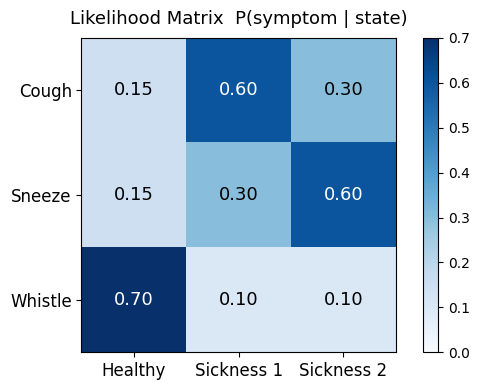

In [4]:
# ── Likelihood heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(L, vmin=0, vmax=0.7, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(STATES, fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels(SYMPTOMS, fontsize=12)
ax.set_title('Likelihood Matrix  P(symptom | state)', fontsize=13, pad=10)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{L[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color='black' if L[i,j] < 0.45 else 'white')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

In [5]:
# ── Generate observations from the true state ────────────────────────────────
data = np.random.choice(3, size=T, p=L[:, TRUE_S])

print(f'True state : {STATES[TRUE_S]}')
print(f'Observations (all {T}): {data}')
print(f'Symptom counts — Cough: {(data==0).sum()}, '
      f'Sneeze: {(data==1).sum()}, Whistle: {(data==2).sum()}')

True state : Sickness 1
Observations (all 100): [0 2 1 0 0 0 0 1 1 1 0 2 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 2 2 1 0
 0 1 0 0 0 0 2 0 1 0 0 0 0 2 1 2 1 0 2 0 0 0 0 0 0 1 0 0 0 0 1 0 2 1 0 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0]
Symptom counts — Cough: 63, Sneeze: 28, Whistle: 9


In [6]:
# ── Belief update algorithms ─────────────────────────────────────────────────

def norm_log(lp):
    """Subtract log-sum-exp so that exp(lp) sums to 1."""
    return lp - logsumexp(lp)

log_prior = norm_log(np.log(prior))
times     = np.arange(T + 1)

# ── Model 1: Optimal Bayesian ────────────────────────────────────────────────
log_b_opt = np.zeros((T + 1, 3))
log_b_opt[0] = log_prior
for t in range(1, T + 1):
    x = data[t - 1]
    log_b_opt[t] = norm_log(log_b_opt[t - 1] + np.log(L[x]))

# ── Model 2: Noisy, no discounting (α = 1) ──────────────────────────────────
# Accumulates all evidence equally, but each log-likelihood is perturbed
rng1 = np.random.default_rng(42)
log_b_noisy = np.zeros((T + 1, 3))
log_b_noisy[0] = log_prior
for t in range(1, T + 1):
    x = data[t - 1]
    noisy_lik = np.log(L[x]) + rng1.normal(0, SIGMA, 3)
    log_b_noisy[t] = norm_log(log_b_noisy[t - 1] + noisy_lik)

# ── Model 3: Noisy + Discounted ──────────────────────────────────────────────
# Recursive: disc_t = (log P(x_t|s) + ε_{s,t}) + α · disc_{t-1}
rng2 = np.random.default_rng(99)
log_b_noisy_disc = np.zeros((T + 1, 3))
log_b_noisy_disc[0] = log_prior
disc_n = np.zeros(3)
for t in range(1, T + 1):
    x = data[t - 1]
    noisy_lik = np.log(L[x]) + rng2.normal(0, SIGMA, 3)
    disc_n = noisy_lik + ALPHA * disc_n
    log_b_noisy_disc[t] = norm_log(log_prior + disc_n)

print(f'Final posteriors at t={T}:')
for label, lb in [('Optimal          ', log_b_opt),
                  ('Noisy (no disc.) ', log_b_noisy),
                  ('Noisy + Discounted', log_b_noisy_disc)]:
    p = np.exp(lb[-1]).round(3)
    print(f'  {label}: {dict(zip(STATES, p))}')

Final posteriors at t=100:
  Optimal          : {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(1.0), 'Sickness 2': np.float64(0.0)}
  Noisy (no disc.) : {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(1.0), 'Sickness 2': np.float64(0.0)}
  Noisy + Discounted: {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(0.796), 'Sickness 2': np.float64(0.204)}


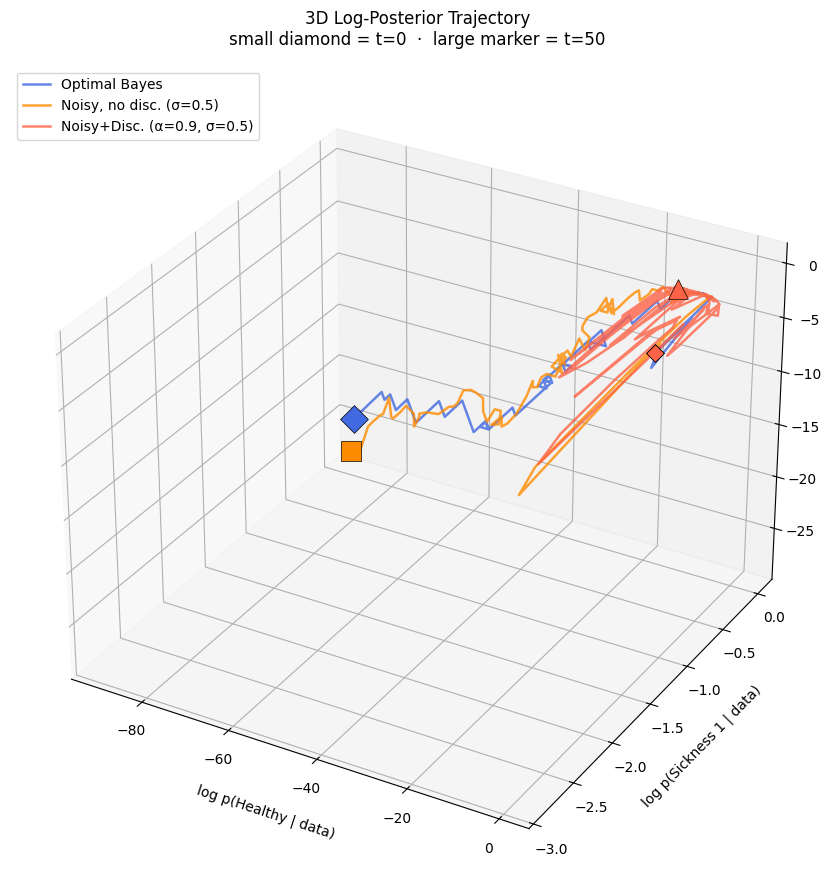

In [7]:
# ── 3D Log-Posterior Trajectory ──────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

configs = [
    (log_b_opt,        'Optimal Bayes',                         'royalblue', 'D'),
    (log_b_noisy,      f'Noisy, no disc. (σ={SIGMA})',          'darkorange','s'),
    (log_b_noisy_disc, f'Noisy+Disc. (α={ALPHA}, σ={SIGMA})',   'tomato',   '^'),
]

for log_b, label, col, mk in configs:
    ax.plot(log_b[:, 0], log_b[:, 1], log_b[:, 2],
            label=label, color=col, alpha=0.80, lw=1.8)
    ax.scatter(*log_b[0],  color=col, marker='D', s=80,  zorder=5, edgecolors='k', lw=0.5)
    ax.scatter(*log_b[-1], color=col, marker=mk,  s=200, zorder=5, edgecolors='k', lw=0.5)

ax.set_xlabel('log p(Healthy | data)',     labelpad=10)
ax.set_ylabel('log p(Sickness 1 | data)', labelpad=10)
ax.set_zlabel('log p(Sickness 2 | data)', labelpad=10)
ax.set_title('3D Log-Posterior Trajectory\n'
             'small diamond = t=0  ·  large marker = t=50', pad=15)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

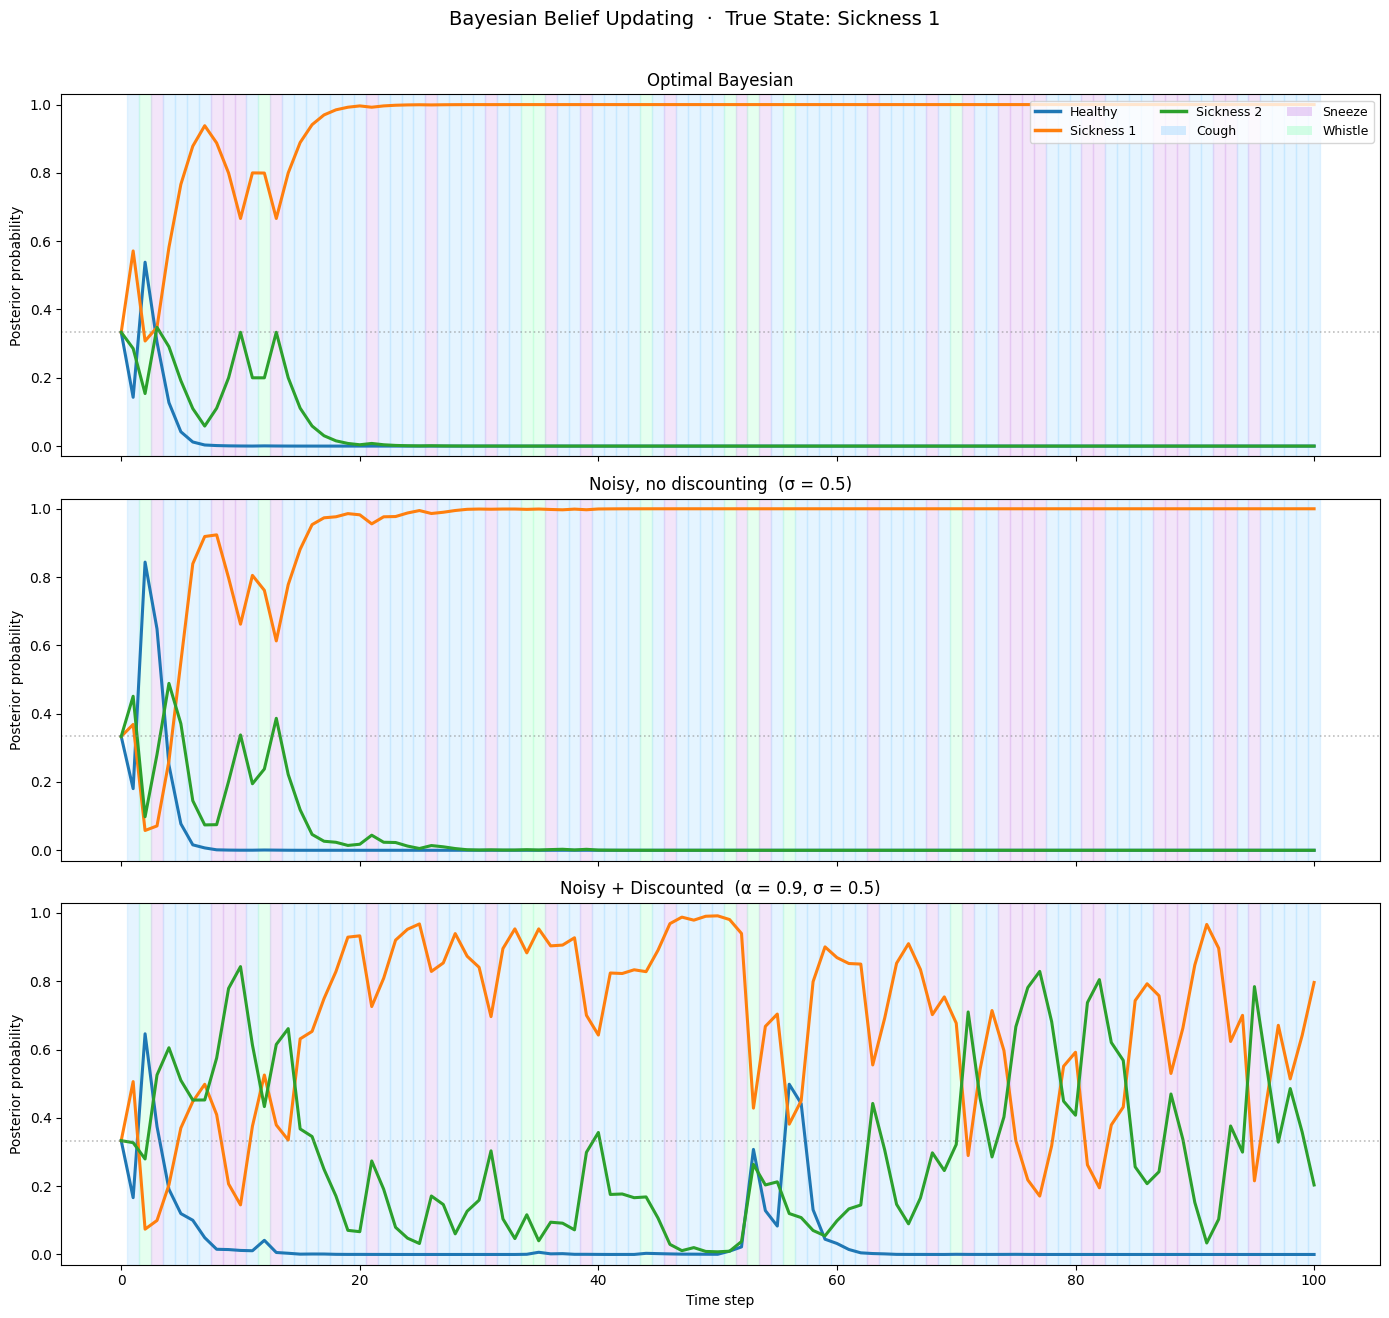

In [8]:
# ── 2D Posterior Probability Traces ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

model_cfg = [
    (log_b_opt,        'Optimal Bayesian'),
    (log_b_noisy,      f'Noisy, no discounting  (σ = {SIGMA})'),
    (log_b_noisy_disc, f'Noisy + Discounted  (α = {ALPHA}, σ = {SIGMA})'),
]
state_cols   = ['tab:blue', 'tab:orange', 'tab:green']
symptom_cols = ['#AADDFF', '#D8AAEE', '#AAFFCC']

for ax, (log_b, title) in zip(axes, model_cfg):
    for t_i, x_i in enumerate(data):
        ax.axvspan(t_i + 0.5, t_i + 1.5, color=symptom_cols[x_i], alpha=0.30)

    probs = np.exp(log_b)
    for s, (state, col) in enumerate(zip(STATES, state_cols)):
        ax.plot(times, probs[:, s], label=state, color=col, lw=2.2)

    ax.axhline(1/3, color='gray', ls=':', alpha=0.5, lw=1.2)
    ax.set_ylabel('Posterior probability')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-0.03, 1.03)

state_lines  = [plt.Line2D([0],[0], color=c, lw=2.5, label=s)
                for c, s in zip(state_cols, STATES)]
sym_patches  = [mpatches.Patch(facecolor=c, alpha=0.5, label=s)
                for c, s in zip(symptom_cols, SYMPTOMS)]
axes[0].legend(handles=state_lines + sym_patches,
               loc='upper right', ncol=3, fontsize=9)

axes[-1].set_xlabel('Time step')
plt.suptitle(f'Bayesian Belief Updating  ·  True State: {STATES[TRUE_S]}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


────────────────────────────────────────────────────────────
  True state: Healthy
  Symptom counts — Cough: 15, Sneeze: 10, Whistle: 75
  Optimal Bayes                            final: [1. 0. 0.]
  Noisy, no disc. (σ=0.5)                  final: [1. 0. 0.]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [1. 0. 0.]


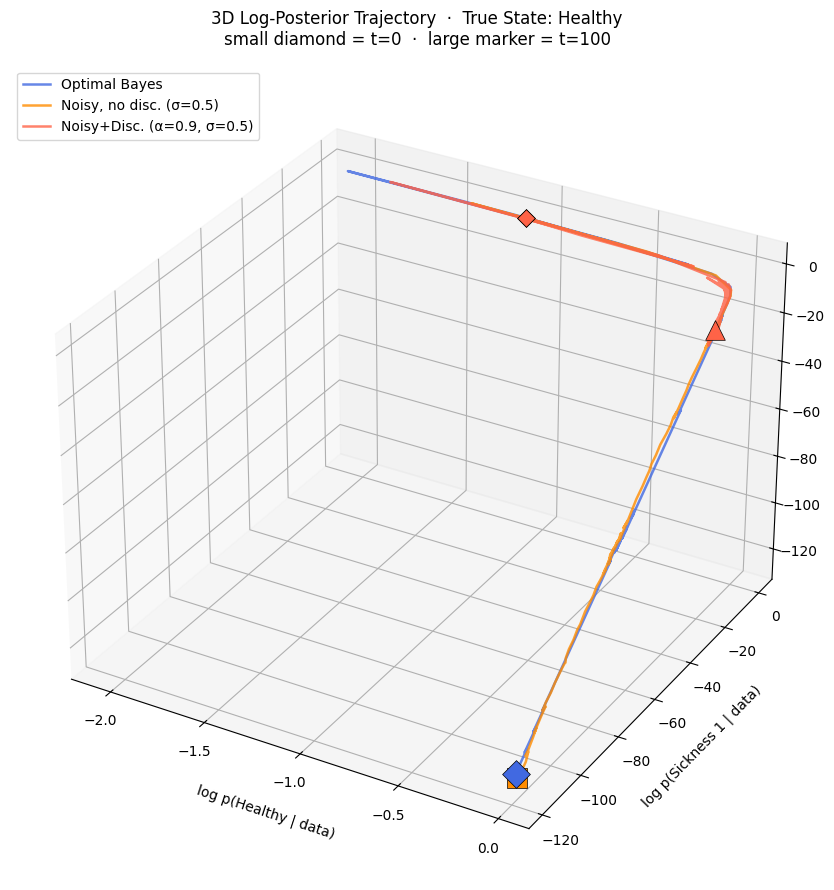

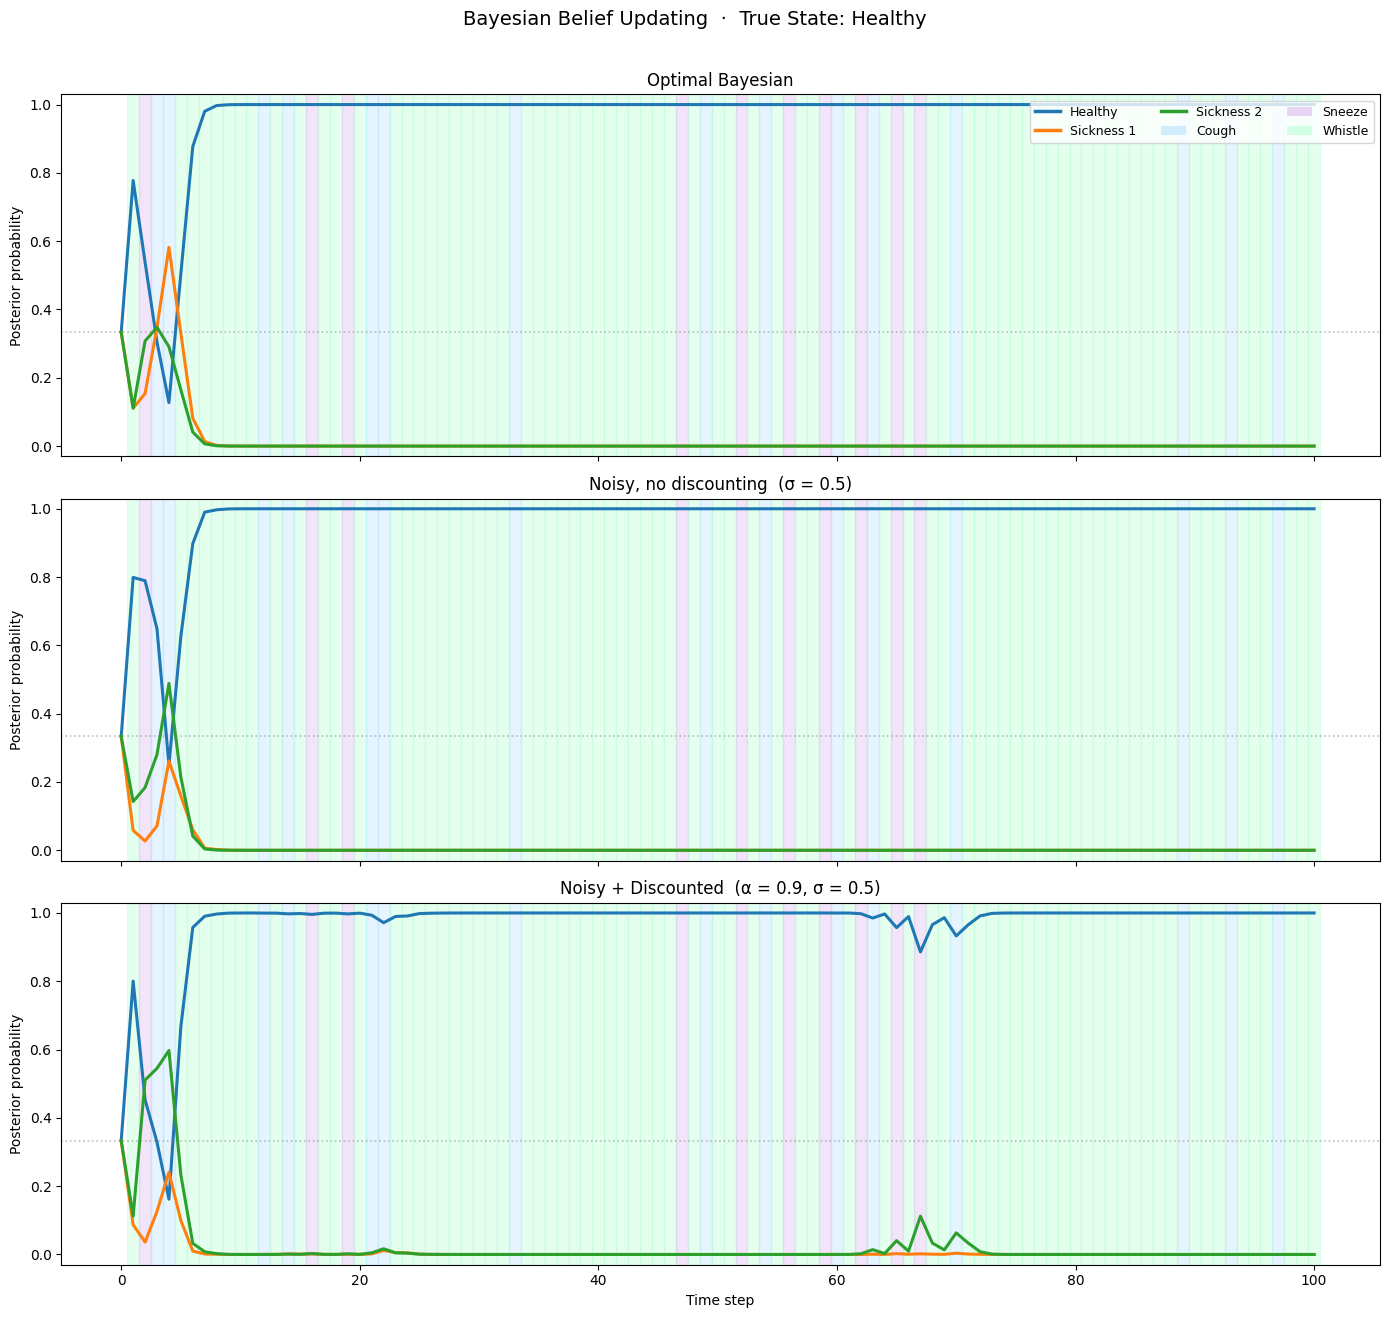


────────────────────────────────────────────────────────────
  True state: Sickness 1
  Symptom counts — Cough: 63, Sneeze: 29, Whistle: 8
  Optimal Bayes                            final: [0. 1. 0.]
  Noisy, no disc. (σ=0.5)                  final: [0. 1. 0.]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [0.    0.995 0.005]


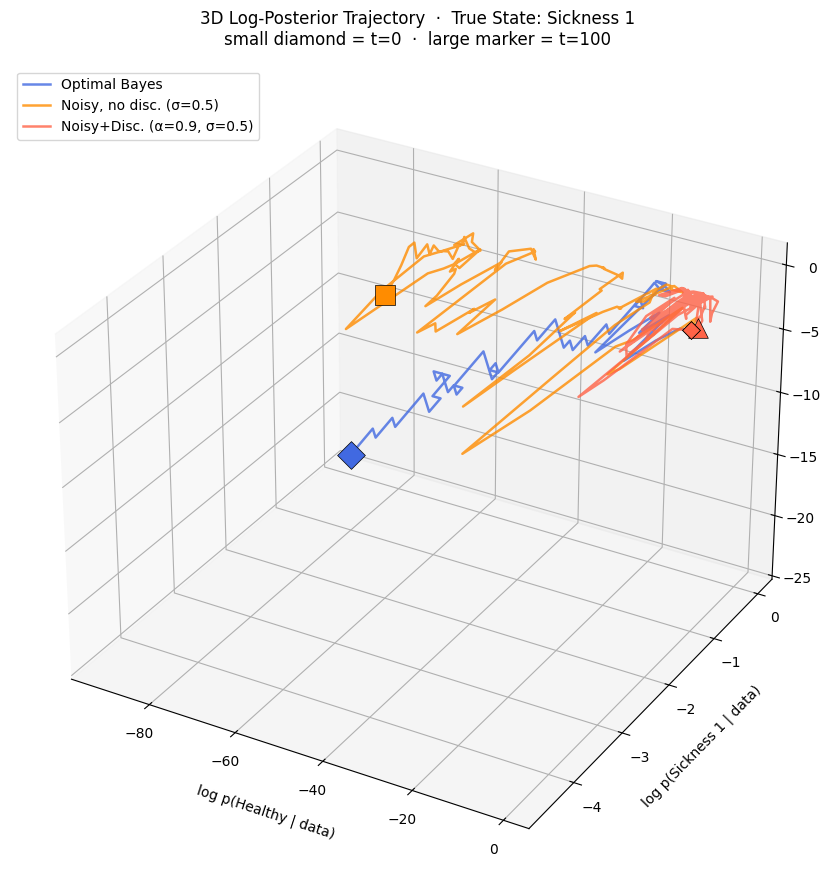

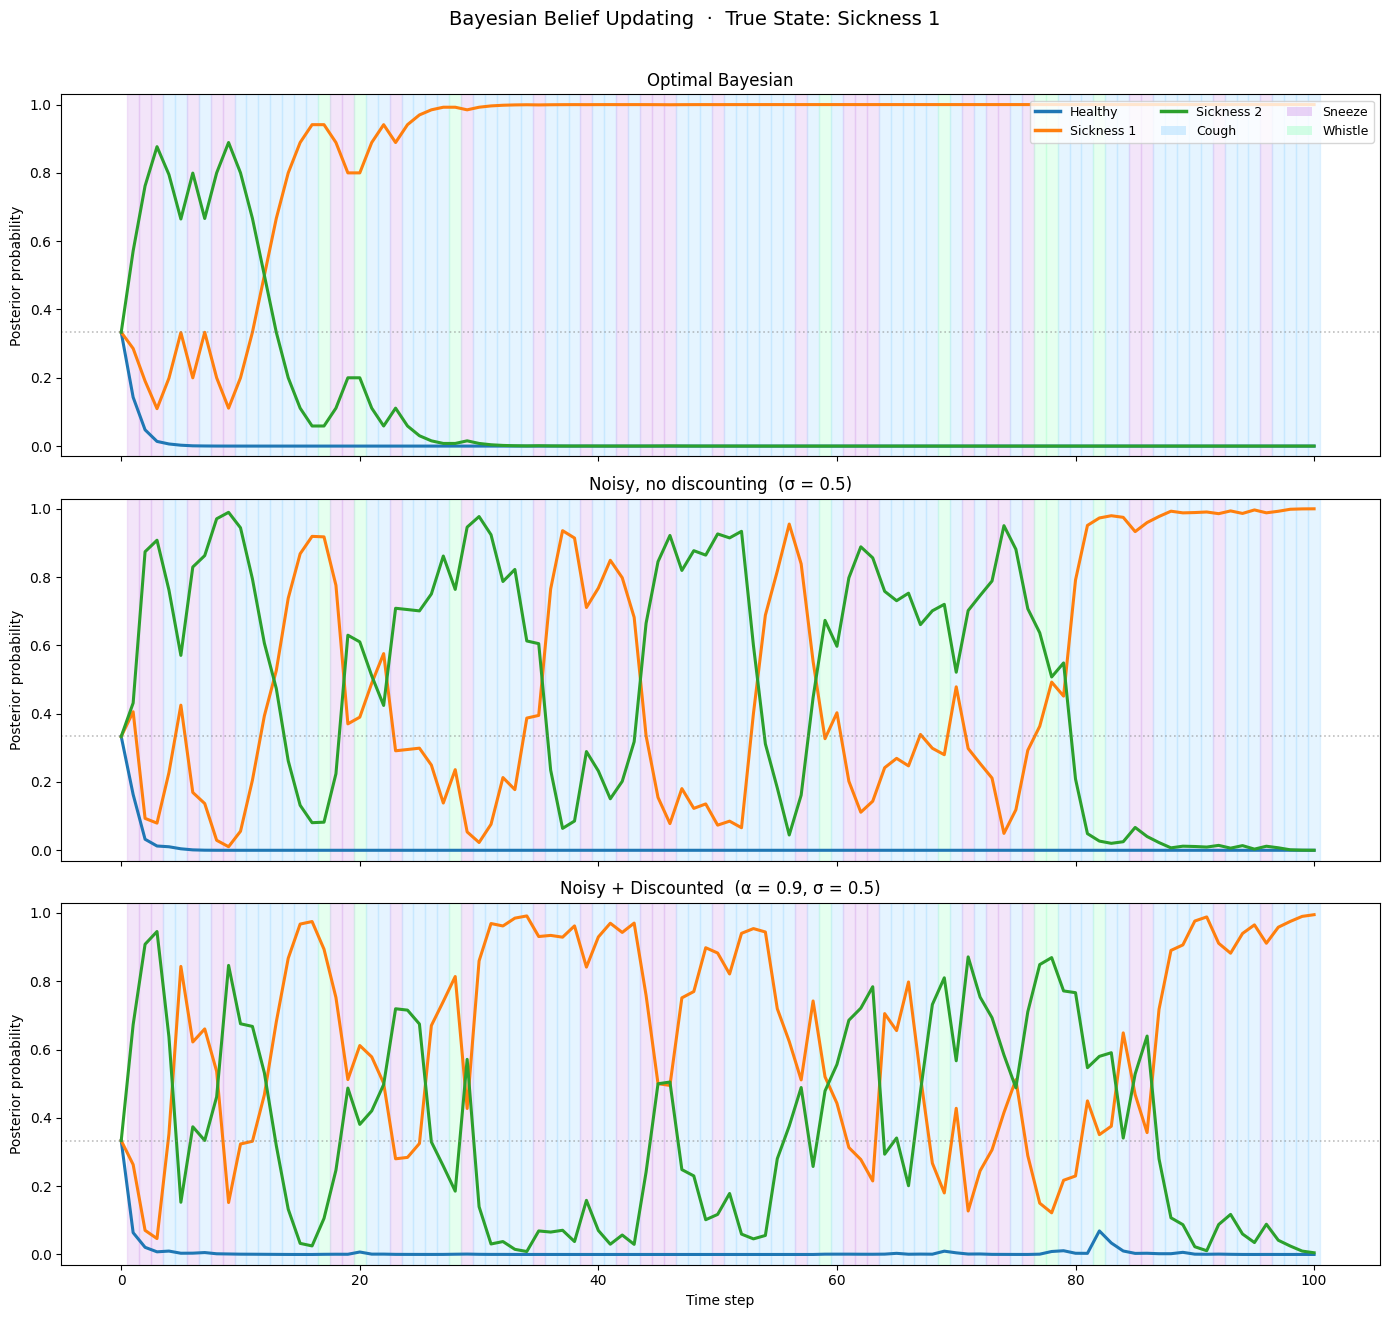


────────────────────────────────────────────────────────────
  True state: Sickness 2
  Symptom counts — Cough: 29, Sneeze: 62, Whistle: 9
  Optimal Bayes                            final: [0. 0. 1.]
  Noisy, no disc. (σ=0.5)                  final: [0. 0. 1.]
  Noisy+Disc. (α=0.9, σ=0.5)               final: [0.    0.058 0.942]


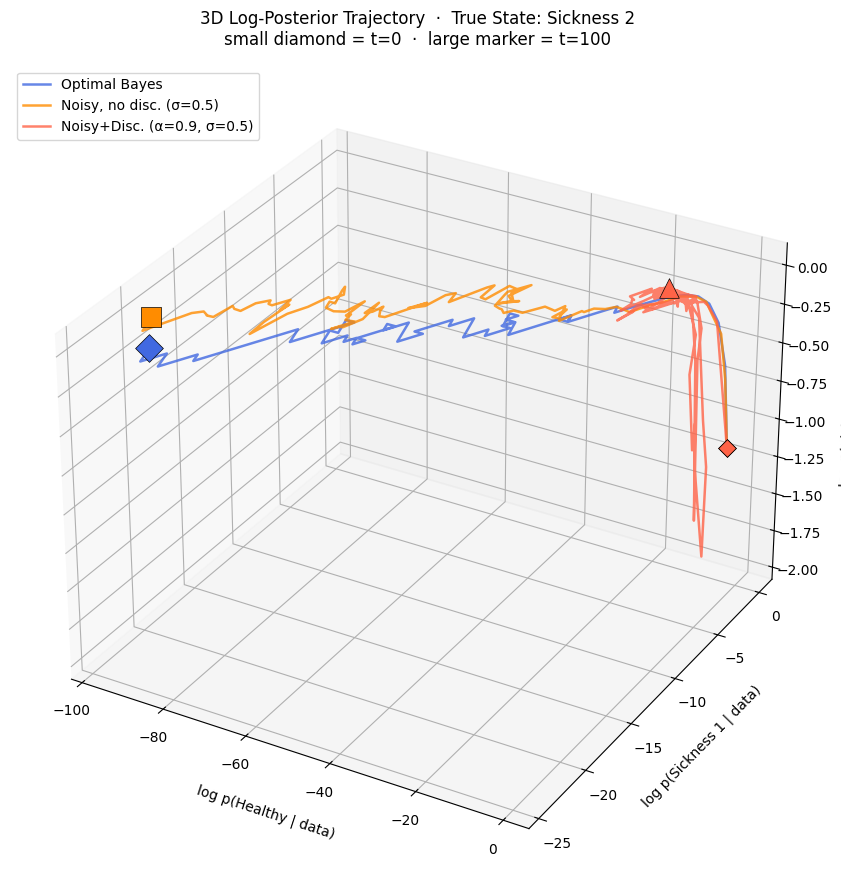

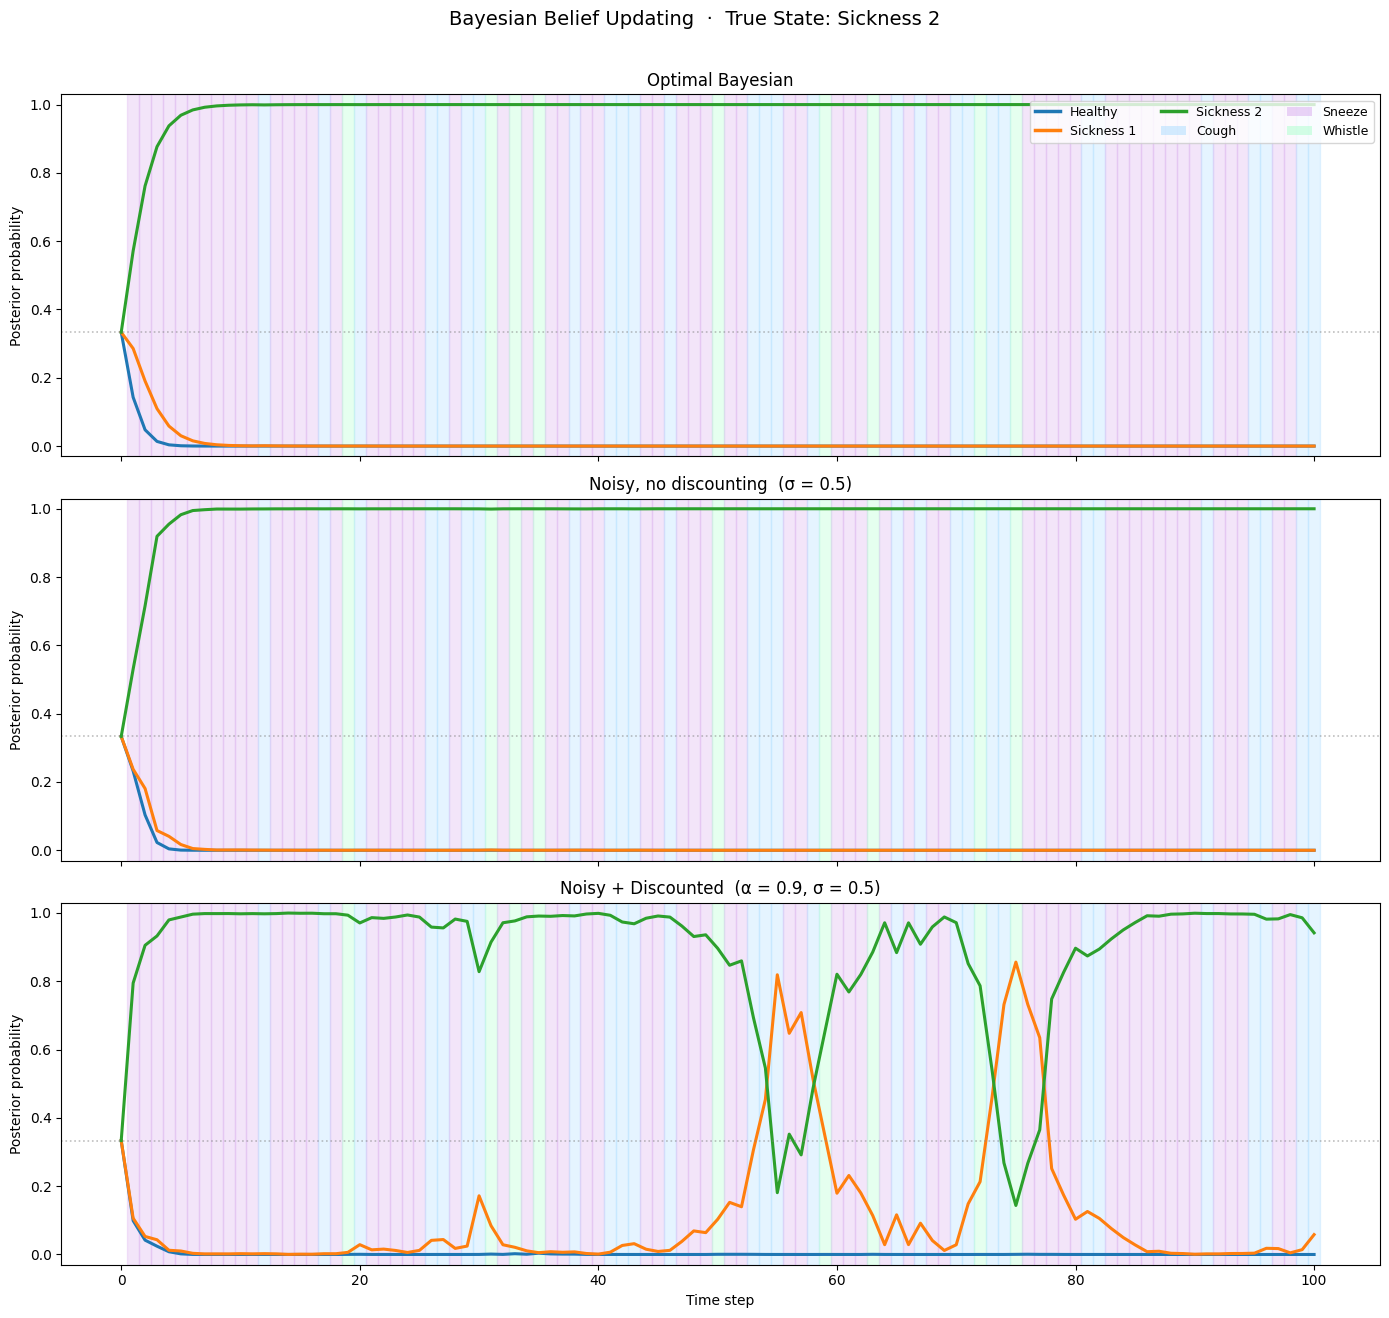

In [9]:
# ── All three true states ────────────────────────────────────────────────────
state_cols   = ['tab:blue', 'tab:orange', 'tab:green']
symptom_cols = ['#AADDFF', '#D8AAEE', '#AAFFCC']

for true_s in range(3):

    # Generate data from this true state
    rng_data = np.random.default_rng(true_s * 7)
    obs = rng_data.choice(3, size=T, p=L[:, true_s])

    # ── Belief updates ────────────────────────────────────────────────────────
    # Model 1: Optimal
    lb_opt = np.zeros((T + 1, 3)); lb_opt[0] = log_prior
    for t in range(1, T + 1):
        lb_opt[t] = norm_log(lb_opt[t - 1] + np.log(L[obs[t - 1]]))

    # Model 2: Noisy, no discounting
    rng1 = np.random.default_rng(42 + true_s)
    lb_noisy = np.zeros((T + 1, 3)); lb_noisy[0] = log_prior
    for t in range(1, T + 1):
        lb_noisy[t] = norm_log(lb_noisy[t - 1] + np.log(L[obs[t - 1]]) + rng1.normal(0, SIGMA, 3))

    # Model 3: Noisy + Discounted
    rng2 = np.random.default_rng(99 + true_s)
    lb_nd = np.zeros((T + 1, 3)); lb_nd[0] = log_prior
    disc  = np.zeros(3)
    for t in range(1, T + 1):
        disc = (np.log(L[obs[t - 1]]) + rng2.normal(0, SIGMA, 3)) + ALPHA * disc
        lb_nd[t] = norm_log(log_prior + disc)

    models = [
        (lb_opt,   'Optimal Bayes',                      'royalblue',  'D'),
        (lb_noisy, f'Noisy, no disc. (σ={SIGMA})',        'darkorange', 's'),
        (lb_nd,    f'Noisy+Disc. (α={ALPHA}, σ={SIGMA})', 'tomato',     '^'),
    ]

    print(f"\n{'─'*60}")
    print(f"  True state: {STATES[true_s]}")
    print(f"  Symptom counts — Cough: {(obs==0).sum()}, Sneeze: {(obs==1).sum()}, Whistle: {(obs==2).sum()}")
    for lb, label, *_ in models:
        print(f"  {label:<40} final: {np.exp(lb[-1]).round(3)}")

    # ── 3D plot ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 9))
    ax  = fig.add_subplot(111, projection='3d')
    for lb, label, col, mk in models:
        ax.plot(lb[:, 0], lb[:, 1], lb[:, 2], label=label, color=col, alpha=0.80, lw=1.8)
        ax.scatter(*lb[0],  color=col, marker='D', s=80,  zorder=5, edgecolors='k', lw=0.5)
        ax.scatter(*lb[-1], color=col, marker=mk,  s=200, zorder=5, edgecolors='k', lw=0.5)
    ax.set_xlabel('log p(Healthy | data)',     labelpad=10)
    ax.set_ylabel('log p(Sickness 1 | data)', labelpad=10)
    ax.set_zlabel('log p(Sickness 2 | data)', labelpad=10)
    ax.set_title(f'3D Log-Posterior Trajectory  ·  True State: {STATES[true_s]}\n'
                 'small diamond = t=0  ·  large marker = t=100', pad=15)
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── 2D plot ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
    model_cfg = [
        (lb_opt,   'Optimal Bayesian'),
        (lb_noisy, f'Noisy, no discounting  (σ = {SIGMA})'),
        (lb_nd,    f'Noisy + Discounted  (α = {ALPHA}, σ = {SIGMA})'),
    ]
    for ax, (lb, title) in zip(axes, model_cfg):
        for t_i, x_i in enumerate(obs):
            ax.axvspan(t_i + 0.5, t_i + 1.5, color=symptom_cols[x_i], alpha=0.30)
        probs = np.exp(lb)
        for s, (state, col) in enumerate(zip(STATES, state_cols)):
            ax.plot(times, probs[:, s], label=state, color=col, lw=2.2)
        ax.axhline(1/3, color='gray', ls=':', alpha=0.5, lw=1.2)
        ax.set_ylabel('Posterior probability')
        ax.set_title(title, fontsize=12)
        ax.set_ylim(-0.03, 1.03)

    state_lines = [plt.Line2D([0],[0], color=c, lw=2.5, label=s)
                   for c, s in zip(state_cols, STATES)]
    sym_patches = [mpatches.Patch(facecolor=c, alpha=0.5, label=s)
                   for c, s in zip(symptom_cols, SYMPTOMS)]
    axes[0].legend(handles=state_lines + sym_patches, loc='upper right', ncol=3, fontsize=9)
    axes[-1].set_xlabel('Time step')
    plt.suptitle(f'Bayesian Belief Updating  ·  True State: {STATES[true_s]}',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

Final posteriors at t=100 (True State: Sickness 1):
  Optimal Bayes         : {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(1.0), 'Sickness 2': np.float64(0.0)}
  No-noise + Discounted : {'Healthy': np.float64(0.0), 'Sickness 1': np.float64(0.933), 'Sickness 2': np.float64(0.067)}


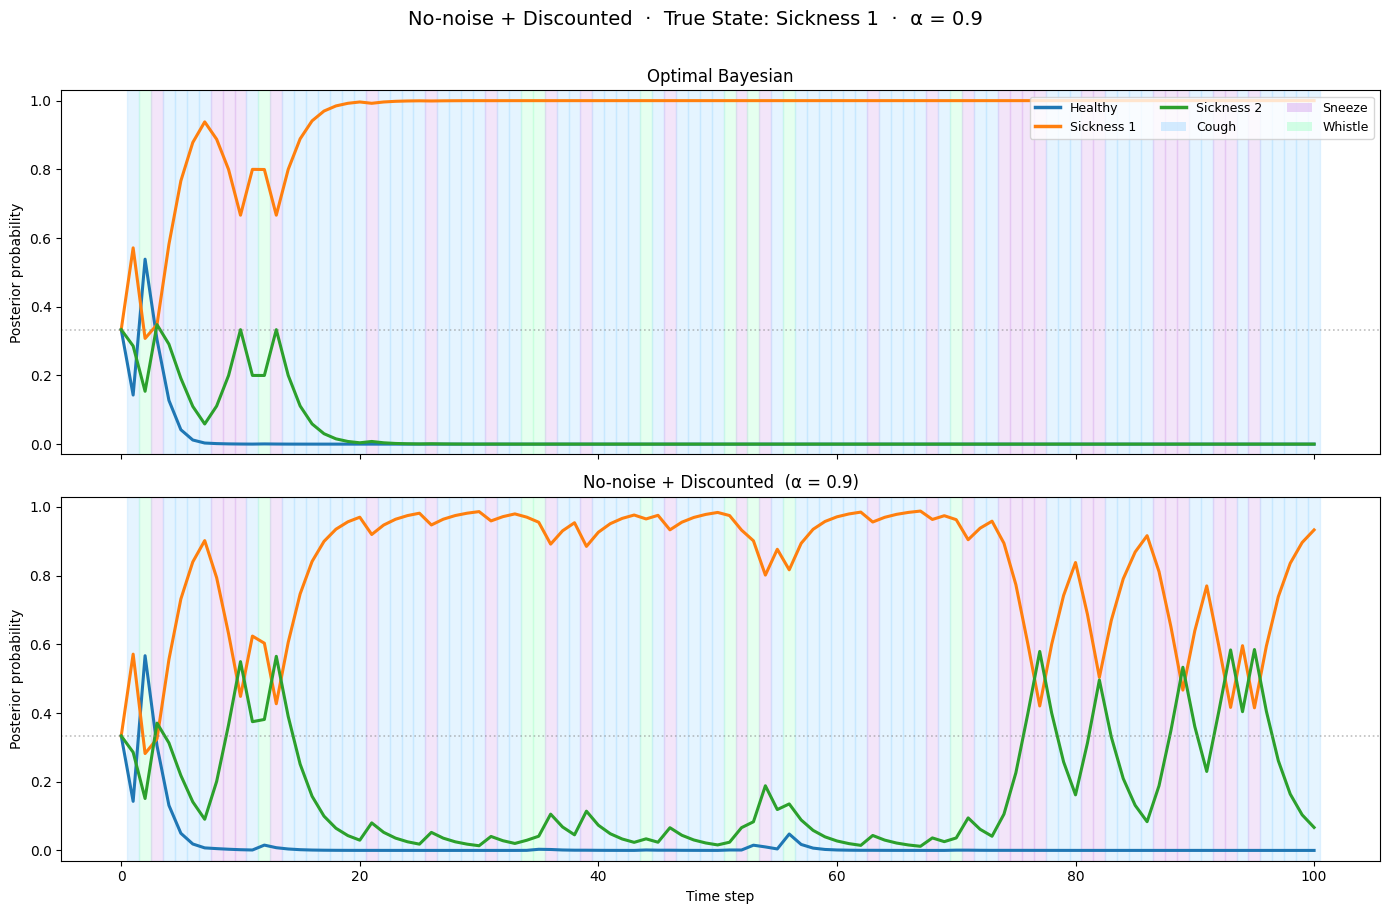

In [10]:
# ── No-noise + Discounted model  (True State: Sickness 1) ───────────────────
# Discounts past evidence by α each step, but no noise perturbation:
#   disc_t = log P(x_t | s) + α · disc_{t-1}
#   log p_t(s) ∝ log_prior + disc_t

log_b_disc = np.zeros((T + 1, 3))
log_b_disc[0] = log_prior
disc = np.zeros(3)
for t in range(1, T + 1):
    x = data[t - 1]
    disc = np.log(L[x]) + ALPHA * disc
    log_b_disc[t] = norm_log(log_prior + disc)

print(f'Final posteriors at t={T} (True State: {STATES[TRUE_S]}):')
for label, lb in [('Optimal Bayes         ', log_b_opt),
                  ('No-noise + Discounted ', log_b_disc)]:
    print(f'  {label}: {dict(zip(STATES, np.exp(lb[-1]).round(3)))}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
state_cols   = ['tab:blue', 'tab:orange', 'tab:green']
symptom_cols = ['#AADDFF', '#D8AAEE', '#AAFFCC']

model_cfg = [
    (log_b_opt,  'Optimal Bayesian'),
    (log_b_disc, f'No-noise + Discounted  (α = {ALPHA})'),
]

for ax, (lb, title) in zip(axes, model_cfg):
    for t_i, x_i in enumerate(data):
        ax.axvspan(t_i + 0.5, t_i + 1.5, color=symptom_cols[x_i], alpha=0.30)
    probs = np.exp(lb)
    for s, (state, col) in enumerate(zip(STATES, state_cols)):
        ax.plot(times, probs[:, s], label=state, color=col, lw=2.2)
    ax.axhline(1/3, color='gray', ls=':', alpha=0.5, lw=1.2)
    ax.set_ylabel('Posterior probability')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-0.03, 1.03)

state_lines = [plt.Line2D([0],[0], color=c, lw=2.5, label=s)
               for c, s in zip(state_cols, STATES)]
sym_patches = [mpatches.Patch(facecolor=c, alpha=0.5, label=s)
               for c, s in zip(symptom_cols, SYMPTOMS)]
axes[0].legend(handles=state_lines + sym_patches, loc='upper right', ncol=3, fontsize=9)
axes[-1].set_xlabel('Time step')
plt.suptitle(f'No-noise + Discounted  ·  True State: {STATES[TRUE_S]}  ·  α = {ALPHA}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()